<a href="https://colab.research.google.com/github/ramyavalipe/GenAIColabNotebooks/blob/main/Unstructured_Data_Analytics_AI_Laws_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pdfminer.six spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 40.6 MB/s eta 0:00:00


In [ ]:
"""
Legislative Document Processing Pipeline
Processes State and Congress bills (with subfolders 118/119)
Outputs JSON files named as: folder_type_billnumber.json
"""

import re
import json
import os
import zipfile
from typing import Dict, List, Tuple
from pathlib import Path
import unicodedata
from datetime import datetime

# PDF text extraction
from pdfminer.high_level import extract_text
from pdfminer.layout import LAParams

# NLP processing
import spacy

class LegislativeDocProcessor:
    def __init__(self, spacy_model: str = "en_core_web_sm"):
        """Initialize the processor with spaCy model"""
        try:
            self.nlp = spacy.load(spacy_model)
        except OSError:
            print(f"Downloading {spacy_model}...")
            import subprocess
            subprocess.run(["python", "-m", "spacy", "download", spacy_model])
            self.nlp = spacy.load(spacy_model)

        # Legislative stopwords in addition to standard ones
        self.legislative_stoplist = {
            'section', 'shall', 'hereby', 'whereas', 'thereof', 'therein',
            'herein', 'aforementioned', 'notwithstanding', 'pursuant',
            'subdivision', 'paragraph', 'subparagraph', 'clause'
        }

        # Words to preserve for regulatory context
        self.preserve_words = {
            'audit', 'register', 'opt-out', 'compliance', 'enforcement',
            'require', 'prohibit', 'liability', 'penalty', 'violation'
        }

    def extract_bill_number(self, filename: str) -> str:
        """Extract bill number from filename (e.g., AB2013, SB100, HR1234, S456, 118_4178)"""
        filename_upper = filename.upper()

        # Try to match common bill patterns (order matters!)
        patterns = [
            # BILLS-119hr1234ih.pdf format (most specific first)
            (r'BILLS-(\d+)(HR|S|HB|SB)(\d+)', lambda m: f"{m.group(2)}{m.group(3)}"),

            # HR1234, S456, HB789, SB100 format
            (r'(HR|S|HB|SB|AB)(\d+)', lambda m: f"{m.group(1)}{m.group(2)}"),

            # 118_4178.pdf or 119_836.pdf format (congress session + bill number)
            (r'(\d{3})_(\d+)', lambda m: f"{m.group(1)}_{m.group(2)}"),

            # Just numbers if 3+ digits (but not if preceded by underscore)
            (r'(?<!_)(\d{3,})', lambda m: m.group(1)),
        ]

        for pattern, formatter in patterns:
            match = re.search(pattern, filename_upper)
            if match:
                bill_num = formatter(match)
                return bill_num

        # If no pattern matches, return filename without extension
        return os.path.splitext(filename)[0]

    def extract_text_from_pdf(self, pdf_path: str) -> str:
        """Step 1: Extract plain text from PDF using pdfminer.six"""
        laparams = LAParams(line_margin=0.5, word_margin=0.1)
        text = extract_text(pdf_path, laparams=laparams)
        return text

    def remove_boilerplate(self, text: str) -> str:
        """
        Step 2: Remove legislative boilerplate, headers, footers, and markup
        Includes: headers, footers, amendment markers (XXX), signatures, legislative markup
        """

        # Remove page numbers and chapter markers
        text = re.sub(r'(?m)^Ch\.\s*\d+—\s*\d+\s*—.*$', '', text)
        text = re.sub(r'(?m)^\d+\s*$', '', text)

        # Remove amendment markers (XXX pattern)
        text = re.sub(r'XXX+', '', text)

        # Remove common header patterns
        text = re.sub(r'(?m)^—\s*\d+\s*—.*$', '', text)

        # Remove signature blocks and filing information
        text = re.sub(r'\[Approved by Governor.*?Secretary of State.*?\]', '', text, flags=re.DOTALL)

        # Remove legislative counsel's digest header
        text = re.sub(r'legislative counsel\s*\'?\s*s digest', '', text, flags=re.IGNORECASE)

        # Remove common footer patterns
        text = re.sub(r'(?m)^\s*\d+\s*$', '', text)

        # Remove excessive whitespace
        text = re.sub(r'\n{3,}', '\n\n', text)
        text = re.sub(r' {2,}', ' ', text)

        return text.strip()

    def extract_metadata_sections(self, text: str) -> Dict[str, List[Tuple[str, int, int]]]:
        """
        Step 3: Tag metadata sections (SECTION, TITLE, FINDINGS, DEFINITIONS, ENFORCEMENT)
        Returns positions for section-level analysis
        """

        sections = {
            'SECTION': [],
            'TITLE': [],
            'FINDINGS': [],
            'DEFINITIONS': [],
            'ENFORCEMENT': [],
            'CHAPTER': [],
            'ARTICLE': [],
            'DIVISION': [],
            'CODE': []
        }

        # Pattern for SECTION markers
        section_pattern = r'(?m)^SECTION\s+\d+\.?'
        for match in re.finditer(section_pattern, text):
            sections['SECTION'].append(('SECTION', match.start(), match.end()))

        # Pattern for TITLE markers
        title_pattern = r'(?m)^TITLE\s+[\d.]+[\w\s:.]+'
        for match in re.finditer(title_pattern, text, re.IGNORECASE):
            sections['TITLE'].append(('TITLE', match.start(), match.end()))

        # Pattern for FINDINGS sections
        findings_pattern = r'(?i)(?:findings?|legislative findings?)'
        for match in re.finditer(findings_pattern, text):
            sections['FINDINGS'].append(('FINDINGS', match.start(), match.end()))

        # Pattern for DEFINITIONS sections
        def_pattern = r'(?i)(?:definitions?|for purposes of this)'
        for match in re.finditer(def_pattern, text):
            sections['DEFINITIONS'].append(('DEFINITIONS', match.start(), match.end()))

        # Pattern for ENFORCEMENT sections
        enforcement_pattern = r'(?i)(?:enforcement|penalties?|violations?)'
        for match in re.finditer(enforcement_pattern, text):
            sections['ENFORCEMENT'].append(('ENFORCEMENT', match.start(), match.end()))

        # Pattern for CHAPTER markers
        chapter_pattern = r'(?m)^CHAPTER\s+\d+'
        for match in re.finditer(chapter_pattern, text):
            sections['CHAPTER'].append(('CHAPTER', match.start(), match.end()))

        return sections

    def normalize_text(self, text: str, preserve_case_for_ner: bool = True) -> str:
        """
        Step 5: Normalize text
        - Unicode normalization
        - Optional lowercasing (preserve case for NER if needed)
        - Contraction expansion not needed for legislative text
        """

        # Unicode normalization (NFKC normalizes compatibility characters)
        text = unicodedata.normalize('NFKC', text)

        # Keep legal capitalizations for NER if specified, otherwise lowercase
        if not preserve_case_for_ner:
            text = text.lower()

        return text

    def sentence_paragraph_split(self, text: str) -> Dict[str, List]:
        """
        Step 4: Split text into sentences and paragraphs using spaCy
        """

        doc = self.nlp(text)

        # Extract sentences
        sentences = [sent.text.strip() for sent in doc.sents]

        # Split by double newlines for paragraphs
        paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]

        return {
            'sentences': sentences,
            'paragraphs': paragraphs
        }

    def tokenize_and_lemmatize(self, text: str,
                               remove_stopwords: bool = True,
                               lowercase_output: bool = True) -> Dict:
        """
        Step 6 & 7: Tokenize, remove stopwords, and lemmatize using spaCy
        - Standard stopwords + legislative stoplist
        - Preserve regulatory words (audit, register, opt-out, etc.)
        - Lemmatization (better than stemming for legal text)
        """

        doc = self.nlp(text)

        tokens = []
        lemmas = []
        pos_tags = []

        for token in doc:
            # Skip punctuation and whitespace
            if token.is_punct or token.is_space:
                continue

            # Check if we should remove this token
            token_lower = token.text.lower()
            if remove_stopwords:
                # Skip standard stopwords unless preserved
                if token.is_stop and token_lower not in self.preserve_words:
                    continue
                # Skip legislative stopwords unless preserved
                if token_lower in self.legislative_stoplist and token_lower not in self.preserve_words:
                    continue

            # Add token
            token_text = token.text.lower() if lowercase_output else token.text
            tokens.append(token_text)

            # Add lemma
            lemma_text = token.lemma_.lower() if lowercase_output else token.lemma_
            lemmas.append(lemma_text)

            # Add POS tag
            pos_tags.append(token.pos_)

        return {
            'tokens': tokens,
            'lemmas': lemmas,
            'pos_tags': pos_tags
        }

    def process_single_document(self, file_path: str, folder_type: str = "") -> Dict:
        """Complete processing pipeline for a single document"""

        print(f"  Processing: {os.path.basename(file_path)}")

        # Step 1: Extract text from PDF
        raw_text = self.extract_text_from_pdf(file_path)

        # Step 2: Remove boilerplate
        cleaned_text = self.remove_boilerplate(raw_text)

        # Step 3: Extract metadata sections
        metadata_sections = self.extract_metadata_sections(cleaned_text)

        # Step 4 & 5: Normalize and split (preserve case for NER)
        normalized_text = self.normalize_text(cleaned_text, preserve_case_for_ner=True)
        splits = self.sentence_paragraph_split(normalized_text)

        # Step 6 & 7: Tokenize and lemmatize (lowercase version)
        normalized_lower = self.normalize_text(cleaned_text, preserve_case_for_ner=False)
        tokens_data = self.tokenize_and_lemmatize(normalized_lower)

        # Extract bill information
        original_filename = os.path.basename(file_path)
        bill_number = self.extract_bill_number(original_filename)

        # Step 8: Store results
        results = {
            'original_filename': original_filename,
            'bill_number': bill_number,
            'folder_type': folder_type,
            'raw_text': raw_text,
            'cleaned_text': cleaned_text,
            'normalized_text': normalized_text,
            'metadata_sections': metadata_sections,
            'sentences': splits['sentences'],
            'paragraphs': splits['paragraphs'],
            'tokens': tokens_data['tokens'],
            'lemmas': tokens_data['lemmas'],
            'pos_tags': tokens_data['pos_tags'],
            'statistics': {
                'num_sentences': len(splits['sentences']),
                'num_paragraphs': len(splits['paragraphs']),
                'num_tokens': len(tokens_data['tokens']),
                'num_unique_lemmas': len(set(tokens_data['lemmas']))
            }
        }

        print(f"    ✓ Bill: {bill_number} | Sentences: {results['statistics']['num_sentences']} | Tokens: {results['statistics']['num_tokens']}")

        return results

    def process_folder(self, folder_path: str, output_folder: str, folder_type: str = "") -> Dict:
        """
        Process all PDF files in a folder

        Args:
            folder_path: Path to folder containing PDF files
            output_folder: Path to save individual processed JSON files
            folder_type: Type identifier (e.g., 'state_bills', 'congress_118')

        Returns:
            Dictionary with processing summary
        """

        # Create output folder
        os.makedirs(output_folder, exist_ok=True)

        # Find all PDF files
        pdf_files = []
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.lower().endswith('.pdf'):
                    pdf_files.append(os.path.join(root, file))

        if not pdf_files:
            print(f"⚠️  No PDF files found in {folder_path}")
            return None

        print(f"\nFound {len(pdf_files)} PDF files in {folder_type}")
        print("="*60)

        # Process each PDF
        all_results = {}
        successful = 0
        failed = 0

        for idx, pdf_path in enumerate(pdf_files, 1):
            print(f"\n[{idx}/{len(pdf_files)}]", end=" ")

            try:
                result = self.process_single_document(pdf_path, folder_type)
                bill_number = result['bill_number']
                all_results[bill_number] = result

                # Save with folder_type_billnumber format
                if folder_type:
                    output_filename = f"{folder_type}_{bill_number}.json"
                else:
                    output_filename = f"{bill_number}.json"

                output_path = os.path.join(output_folder, output_filename)

                with open(output_path, 'w', encoding='utf-8') as f:
                    json.dump(result, f, indent=2, ensure_ascii=False)

                print(f"    ✓ Saved: {output_filename}")

                successful += 1

            except Exception as e:
                print(f"    ✗ ERROR: {str(e)}")
                failed += 1
                filename = os.path.basename(pdf_path)
                all_results[filename] = {'error': str(e)}

        # Create summary
        summary = {
            'processing_date': datetime.now().isoformat(),
            'folder_type': folder_type,
            'total_files': len(pdf_files),
            'successful': successful,
            'failed': failed,
            'documents': all_results
        }

        # Save summary
        summary_path = os.path.join(output_folder, f'{folder_type}_summary.json')
        with open(summary_path, 'w', encoding='utf-8') as f:
            json.dump(summary, f, indent=2, ensure_ascii=False)

        print(f"\n{'='*60}")
        print(f"SUMMARY - {folder_type.upper()}")
        print(f"{'='*60}")
        print(f"Total files: {len(pdf_files)}")
        print(f"Successfully processed: {successful}")
        print(f"Failed: {failed}")
        print(f"✓ Summary saved: {summary_path}")

        if successful > 0:
            total_sentences = sum(doc['statistics']['num_sentences']
                                for doc in all_results.values()
                                if 'statistics' in doc)
            total_tokens = sum(doc['statistics']['num_tokens']
                             for doc in all_results.values()
                             if 'statistics' in doc)

            print(f"\nAggregate Statistics:")
            print(f"  Total sentences: {total_sentences}")
            print(f"  Total tokens: {total_tokens}")
            print(f"  Average tokens per bill: {total_tokens / successful:.0f}")

        return summary


# ============================================================
# MAIN EXECUTION
# ============================================================

if __name__ == "__main__":
    base_path = "/content"

    print("="*70)
    print("LEGISLATIVE BILL PROCESSING PIPELINE")
    print("="*70)

    # ============================================================
    # STEP 1: Unzip folders
    # ============================================================
    print("\n" + "="*70)
    print("STEP 1: UNZIPPING FOLDERS")
    print("="*70)

    # Unzip state bills
    state_zip = os.path.join(base_path, "state_bills.zip")
    if os.path.exists(state_zip):
        print("\nUnzipping state_bills.zip...")
        with zipfile.ZipFile(state_zip, 'r') as zip_ref:
            zip_ref.extractall(base_path)
        print("✓ State bills unzipped")
    else:
        print("⚠️  state_bills.zip not found")

    # Unzip congress bills
    congress_zip = os.path.join(base_path, "congress_bills.zip")
    if os.path.exists(congress_zip):
        print("\nUnzipping congress_bills.zip...")
        with zipfile.ZipFile(congress_zip, 'r') as zip_ref:
            zip_ref.extractall(base_path)
        print("✓ Congress bills unzipped")
    else:
        print("⚠️  congress_bills.zip not found")

    # ============================================================
    # STEP 2: Process PDFs to JSON
    # ============================================================
    print("\n" + "="*70)
    print("STEP 2: PROCESSING PDFs TO JSON")
    print("="*70)

    # Initialize processor
    processor = LegislativeDocProcessor()

    # Define folder structure
    folders = {
        'state_bills': {
            'input': os.path.join(base_path, "state_bills"),
            'output': os.path.join(base_path, "processed_state_bills")
        },
        'congress_118': {
            'input': os.path.join(base_path, "congress_bills/118"),
            'output': os.path.join(base_path, "processed_congress_118")
        },
        'congress_119': {
            'input': os.path.join(base_path, "congress_bills/119"),
            'output': os.path.join(base_path, "processed_congress_119")
        }
    }

    # Process each folder
    all_summaries = {}

    for folder_name, paths in folders.items():
        print(f"\n{'='*70}")
        print(f"PROCESSING: {folder_name.upper()}")
        print(f"{'='*70}")

        if os.path.exists(paths['input']):
            summary = processor.process_folder(
                folder_path=paths['input'],
                output_folder=paths['output'],
                folder_type=folder_name
            )
            if summary:
                all_summaries[folder_name] = summary
        else:
            print(f"⚠️  Folder not found: {paths['input']}")

    # ============================================================
    # STEP 3: Save combined summary
    # ============================================================
    print("\n" + "="*70)
    print("STEP 3: SAVING COMBINED SUMMARY")
    print("="*70)

    combined_summary = {
        'processing_date': datetime.now().isoformat(),
        'datasets_processed': list(all_summaries.keys()),
        'summary_by_dataset': {}
    }

    for dataset_name, summary in all_summaries.items():
        combined_summary['summary_by_dataset'][dataset_name] = {
            'total_files': summary['total_files'],
            'successful': summary['successful'],
            'failed': summary['failed'],
            'output_folder': folders[dataset_name]['output']
        }

    combined_summary_path = os.path.join(base_path, 'combined_processing_summary.json')
    with open(combined_summary_path, 'w', encoding='utf-8') as f:
        json.dump(combined_summary, f, indent=2, ensure_ascii=False)

    print(f"\n✓ Combined summary saved: {combined_summary_path}")

    # ============================================================
    # FINAL SUMMARY
    # ============================================================
    print("\n" + "="*70)
    print("PROCESSING COMPLETE!")
    print("="*70)

    print("\nProcessed Datasets:")
    for dataset_name, summary in all_summaries.items():
        print(f"\n{dataset_name.upper()}:")
        print(f"  Location: {folders[dataset_name]['output']}")
        print(f"  Bills processed: {summary['successful']}/{summary['total_files']}")
        if summary['failed'] > 0:
            print(f"  Failed: {summary['failed']}")

    print(f"\n✓ All JSON files saved with naming format: [folder_type]_[bill_number].json")
    print(f"✓ Check individual folders for processed bills")
    print(f"✓ Combined summary: {combined_summary_path}")

LEGISLATIVE BILL PROCESSING PIPELINE

STEP 1: UNZIPPING FOLDERS

Unzipping state_bills.zip...
✓ State bills unzipped

Unzipping congress_bills.zip...
✓ Congress bills unzipped

STEP 2: PROCESSING PDFs TO JSON

PROCESSING: STATE_BILLS

Found 12 PDF files in state_bills

[1/12]   Processing: H97.pdf
    ✓ Bill: H97 | Sentences: 95 | Tokens: 3647
    ✓ Saved: state_bills_H97.json

[2/12]   Processing: https:s3.us-west-2.amazonaws.com:beta.leg.colorado.gov:8ae60739b2b5dac9235add08baebc925.pdf
    ✓ Bill: S3 | Sentences: 142 | Tokens: 3750
    ✓ Saved: state_bills_S3.json

[3/12]   Processing: billTextClient.xhtml.pdf
    ✓ Bill: billTextClient.xhtml | Sentences: 253 | Tokens: 3851
    ✓ Saved: state_bills_billTextClient.xhtml.json

[4/12]   Processing: billNavClient.xhtml.pdf
    ✓ Bill: billNavClient.xhtml | Sentences: 38 | Tokens: 588
    ✓ Saved: state_bills_billNavClient.xhtml.json

[5/12]   Processing: A6453B.pdf
    ✓ Bill: 6453 | Sentences: 81 | Tokens: 1477
    ✓ Saved: state_bills

In [ ]:
import zipfile
import os
from google.colab import files
from datetime import datetime # Import datetime

# Define the directories to zip
# Using the 'folders' variable from the previous execution context
# to get the output paths
folders_to_download = [
    '/content/processed_state_bills',
    '/content/processed_congress_118',
    '/content/processed_congress_119'
]

for data_directory in folders_to_download:
    if os.path.exists(data_directory):
        # Use the folder name for the zip file
        zip_filename = f'{os.path.basename(data_directory)}_{datetime.now().strftime("%Y%m%d_%H%M%S")}.zip'

        print(f"\nCreating zip archive for '{data_directory}'...")
        with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for root, _, files_in_dir in os.walk(data_directory):
                for file in files_in_dir:
                    file_path = os.path.join(root, file)
                    # Add file to zip, preserving directory structure within the zip
                    zipf.write(file_path, os.path.relpath(file_path, data_directory))

        print(f"Successfully created zip archive: {zip_filename}")
        files.download(zip_filename)
        print(f"Download initiated for {zip_filename}.")
    else:
        print(f"The directory '{data_directory}' does not exist. Skipping.")

print("\nAll requested downloads initiated.")


Creating zip archive for '/content/processed_state_bills'...
Successfully created zip archive: processed_state_bills_20251207_201736.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated for processed_state_bills_20251207_201736.zip.

Creating zip archive for '/content/processed_congress_118'...
Successfully created zip archive: processed_congress_118_20251207_201736.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated for processed_congress_118_20251207_201736.zip.

Creating zip archive for '/content/processed_congress_119'...
Successfully created zip archive: processed_congress_119_20251207_201736.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated for processed_congress_119_20251207_201736.zip.

All requested downloads initiated.


# Load All Bill Files

In [ ]:
import os
import json

# Mount Google Drive first
# from google.colab import drive
# drive.mount('/content/drive')

DATA_DIR = "/content/"  # Update this path

bill_docs = []

# Load Congress 118 bills
congress_118_path = os.path.join(DATA_DIR, "processed_congress_118")
if os.path.exists(congress_118_path):
    for file in os.listdir(congress_118_path):
        # Skip summary files
        if file.endswith(".json") and not file.endswith("summary.json"):
            with open(os.path.join(congress_118_path, file), "r", encoding='utf-8') as f:
                doc = json.load(f)
                doc["congress"] = 118
                doc["is_state"] = False
                bill_docs.append(doc)

# Load Congress 119 bills
congress_119_path = os.path.join(DATA_DIR, "processed_congress_119")
if os.path.exists(congress_119_path):
    for file in os.listdir(congress_119_path):
        # Skip summary files
        if file.endswith(".json") and not file.endswith("summary.json"):
            with open(os.path.join(congress_119_path, file), "r", encoding='utf-8') as f:
                doc = json.load(f)
                doc["congress"] = 119
                doc["is_state"] = False
                bill_docs.append(doc)

# Load State bills
state_bills_path = os.path.join(DATA_DIR, "processed_state_bills")
if os.path.exists(state_bills_path):
    for file in os.listdir(state_bills_path):
        # Skip summary files
        if file.endswith(".json") and not file.endswith("summary.json"):
            with open(os.path.join(state_bills_path, file), "r", encoding='utf-8') as f:
                doc = json.load(f)
                doc["congress"] = None
                doc["is_state"] = True
                bill_docs.append(doc)

print(f"✓ Loaded {len(bill_docs)} bills total")
print(f"  • Congress 118: {sum(1 for d in bill_docs if d.get('congress') == 118)}")
print(f"  • Congress 119: {sum(1 for d in bill_docs if d.get('congress') == 119)}")
print(f"  • State bills: {sum(1 for d in bill_docs if d['is_state'])}")

✓ Loaded 48 bills total
  • Congress 118: 18
  • Congress 119: 18
  • State bills: 12


# Category Frequency Count (FEDERAL and Texas SB 1964)

https://iapp.org/media/pdf/resource_center/us_state_ai_governance_legislation_tracker.pdf

In [ ]:

categories = {
    "Governance": [
        "assessment", "risk assessment", "documentation", "program",
        "training", "responsible", "impact assessment", "oversight", "governance"
    ],
    "Transparency": [
        "notice", "inform", "label", "explain", "public disclosure",
        "incident", "incident report", "developer documentation", "transparency", "transparent"
    ],
    "Assurance": [
        "registration", "certification", "audit", "third-party", "external assessment", "assurance", "assure"
    ],
    "IndividualRights": [
        "opt out", "appeal", "access", "correction", "discrimination", "non-discrimination", "individual rights"
    ]
}


In [ ]:
import re
import pandas as pd

results = []

for bill in bill_docs:
    text = bill["cleaned_text"].lower()

    # Use fields that actually exist in your JSON
    row = {
        "bill_number": bill["bill_number"],
        "folder_type": bill["folder_type"],
        "is_state": bill["is_state"],
        "congress": bill.get("congress")  # Use .get() in case it's None for state bills
    }

    for cat, keywords in categories.items():
        count = sum(len(re.findall(k, text)) for k in keywords)
        row[cat] = 1 if count >= 3 else 0  # threshold rule
        row[f"{cat}_count"] = count

    results.append(row)

freq_df = pd.DataFrame(results)
print(f"Created frequency dataframe with {len(freq_df)} bills")
freq_df.head()

Created frequency dataframe with 48 bills


,bill_number,folder_type,is_state,congress,Governance,Governance_count,Transparency,Transparency_count,Assurance,Assurance_count,IndividualRights,IndividualRights_count
0,S66,congress_118,False,118.0,0,0,0,0,0,0,0,0
1,118_4769,congress_118,False,118.0,1,10,1,5,1,46,0,0
2,S1356,congress_118,False,118.0,1,13,1,8,0,2,1,3
3,118_5616,congress_118,False,118.0,1,8,1,10,0,0,1,5
4,HR1718,congress_118,False,118.0,0,0,0,0,0,0,0,0


In [ ]:
# Summary Statistics
print("="*60)
print("STATE BILLS - CATEGORY FREQUENCY")
print("="*60)
state_freq = freq_df[freq_df["is_state"] == True]
total_state = len(state_freq)

for cat in ["Governance", "Transparency", "Assurance", "IndividualRights"]:
    count = state_freq[cat].sum()
    pct = (count/total_state*100) if total_state > 0 else 0
    print(f"{cat:20s}: {count:3d}/{total_state:3d} bills ({pct:5.1f}%)")

print("\n" + "="*60)
print("FEDERAL BILLS - CATEGORY FREQUENCY")
print("="*60)
fed_freq = freq_df[freq_df["is_state"] == False]
total_fed = len(fed_freq)

for cat in ["Governance", "Transparency", "Assurance", "IndividualRights"]:
    count = fed_freq[cat].sum()
    pct = (count/total_fed*100) if total_fed > 0 else 0
    print(f"{cat:20s}: {count:3d}/{total_fed:3d} bills ({pct:5.1f}%)")

STATE BILLS - CATEGORY FREQUENCY
Governance          :   8/ 12 bills ( 66.7%)
Transparency        :   9/ 12 bills ( 75.0%)
Assurance           :   5/ 12 bills ( 41.7%)
IndividualRights    :   7/ 12 bills ( 58.3%)

FEDERAL BILLS - CATEGORY FREQUENCY
Governance          :  13/ 36 bills ( 36.1%)
Transparency        :  16/ 36 bills ( 44.4%)
Assurance           :   4/ 36 bills ( 11.1%)
IndividualRights    :   8/ 36 bills ( 22.2%)


Might need to also categorize bills as federal vs state depending on setup

# Fastest Growing Topic (FEDERAL ONLY)

In [ ]:
# Filter to federal bills only for growth analysis
freq_df_fed = freq_df[freq_df["is_state"] == False].copy()

# Calculate growth
growth = freq_df_fed.groupby("congress")[["Governance","Transparency","Assurance","IndividualRights"]].sum()

# Check if we have both congresses
if 118 in growth.index and 119 in growth.index:
    pct_change = ((growth.loc[119] - growth.loc[118]) / growth.loc[118] * 100)

    print("="*60)
    print("CATEGORY GROWTH (118th → 119th Congress)")
    print("="*60)
    for cat in pct_change.sort_values(ascending=False).index:
        print(f"{cat:20s}: {pct_change[cat]:+6.1f}%")
    print("="*60)
else:
    print("Error: Missing congress data")
    print(f"Available congresses: {growth.index.tolist()}")

CATEGORY GROWTH (118th → 119th Congress)
Governance          :  -14.3%
Transparency        :  -40.0%
IndividualRights    :  -40.0%
Assurance           : -100.0%


# TF-IDF (State vs Federal)

In [ ]:
# state_texts = [d["normalized_text"] for d in bill_docs if d["is_state"] == True]
# fed_texts   = [d["normalized_text"] for d in bill_docs if d["is_state"] == False]
# Replace your TF-IDF loading code
state_texts = [d.get("normalized_text", d.get("cleaned_text", ""))
               for d in bill_docs if d["is_state"]]
fed_texts = [d.get("normalized_text", d.get("cleaned_text", ""))
             for d in bill_docs if not d["is_state"]]

print(f"State corpus: {len(state_texts)} bills")
print(f"Federal corpus: {len(fed_texts)} bills")

State corpus: 12 bills
Federal corpus: 36 bills


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Better text cleaning function
def clean_for_tfidf(text):
    # Remove numbers and short tokens
    text = re.sub(r'\b\d+\b', '', text)  # Remove standalone numbers
    text = re.sub(r'\b[a-z]{1,2}\b', '', text)  # Remove 1-2 letter words
    return text

# Clean texts before TF-IDF
state_texts = [clean_for_tfidf(d["normalized_text"])
               for d in bill_docs if d["is_state"]]
fed_texts = [clean_for_tfidf(d["normalized_text"])
             for d in bill_docs if not d["is_state"]]

# Custom stopwords: months, metadata, and common noise
custom_stopwords = list(set([
    # Months
    'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec',
    'january', 'february', 'march', 'april', 'june', 'july', 'august', 'september',
    'october', 'november', 'december',
    # Bill metadata terms
    'jkt', 'verdate', 'fmt', 'sfmt', 'frm', 'bills', 'congress',
    # Common noise from PDFs
    'ih', 'iii', 'sec', 'usc', 'act', 'bill', 'section', 'subsection',
    # Add English stopwords
] + list(TfidfVectorizer(stop_words='english').get_stop_words())))

# Fit separate vectorizers for state and federal
state_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.85,
    token_pattern=r'\b[a-z]{3,}\b',
    stop_words=custom_stopwords  # Use custom stopwords
)

fed_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.85,
    token_pattern=r'\b[a-z]{3,}\b',
    stop_words=custom_stopwords  # Use custom stopwords
)

tfidf_state = state_vectorizer.fit_transform(state_texts)
tfidf_fed = fed_vectorizer.fit_transform(fed_texts)

state_terms = state_vectorizer.get_feature_names_out()
fed_terms = fed_vectorizer.get_feature_names_out()

print(f"State corpus: {len(state_texts)} bills, {len(state_terms)} terms")
print(f"Federal corpus: {len(fed_texts)} bills, {len(fed_terms)} terms")

State corpus: 12 bills, 3000 terms
Federal corpus: 36 bills, 3000 terms


In [ ]:
import numpy as np

def top_terms(matrix, feature_names, n=20):
    avg = matrix.mean(axis=0)
    indices = np.array(avg).argsort()[0][-n:]
    return [feature_names[i] for i in indices]

top_state_terms = top_terms(tfidf_state, state_terms)
top_fed_terms   = top_terms(tfidf_fed, fed_terms)

top_state_terms, top_fed_terms


(['code',
  'agency',
  'attorney',
  'covered',
  'model',
  'systems',
  'information',
  'means',
  'high',
  'high risk',
  'consumer',
  'use',
  'risk artificial',
  'data',
  'deployer',
  'person',
  'developer',
  'chapter',
  'risk',
  'frontier'],
 ['title',
  'standards',
  'technology',
  'generative artificial',
  'security',
  'services',
  'information',
  'including',
  'financial',
  'program',
  'director',
  'generative',
  'systems',
  'covered',
  'federal',
  'national',
  'use',
  'term',
  'secretary',
  'shall'])

# Topic Modeling (LDA - State vs. Federal)

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.6 MB/s eta 0:00:00


In [ ]:
from gensim import corpora
from gensim.models.ldamodel import LdaModel
import re

# Define stopwords for LDA (similar to TF-IDF but for lemmas)
lda_stopwords = set([
    # Months
    'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec',
    'january', 'february', 'march', 'april', 'june', 'july', 'august', 'september',
    'october', 'november', 'december',
    # Bill metadata
    'jkt', 'verdate', 'fmt', 'sfmt', 'frm', 'bills', 'po', 'rs',
    # Common noise
    'ih', 'iii', 'iv', 'sec', 'usc', 'act', 'bill', 'section', 'subsection',
    # Single letters that appear as lemmas
    'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
    'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z',
    # Numbers as words
    '1', '2', '3', '4', '5', '6', '7', '8', '9', '0',
    # Symbols
    '$', '•s', 'Ã¦', '†',
    # Common structure words
    'shall', 'mean', 'include', 'provide', 'require', 'pursuant'
])

def clean_lemmas(lemma_list):
    """Filter out noise from lemmas"""
    cleaned = []
    for token in lemma_list:
        token_lower = token.lower()
        # Keep only if:
        # - Length >= 3
        # - Not in stopwords
        # - Not a number
        # - Not just punctuation/symbols
        if (len(token_lower) >= 3 and
            token_lower not in lda_stopwords and
            not token_lower.isdigit() and
            not re.match(r'^[^a-z]+$', token_lower)):
            cleaned.append(token_lower)
    return cleaned

# Clean lemmas before using them
texts_state = [clean_lemmas(bill["lemmas"]) for bill in bill_docs if bill["is_state"]]
texts_fed = [clean_lemmas(bill["lemmas"]) for bill in bill_docs if not bill["is_state"]]

print(f"State corpus: {len(texts_state)} bills")
print(f"Federal corpus: {len(texts_fed)} bills")
print(f"Sample cleaned state lemmas: {texts_state[0][:20]}")  # Show first 20 tokens

State corpus: 12 bills
Federal corpus: 36 bills
Sample cleaned state lemmas: ['senate', 'chapter', 'add', 'chapter', 'commence', 'division', 'business', 'profession', 'code', 'relate', 'consumer', 'protection', 'legislative', 'counsel', 'digest', 'becker', 'california', 'transparency', 'exist', 'law']


In [ ]:
# Build dictionaries
state_dict = corpora.Dictionary(texts_state)
fed_dict = corpora.Dictionary(texts_fed)

print(f"\nBefore filtering:")
print(f"  State dictionary: {len(state_dict)} unique tokens")
print(f"  Federal dictionary: {len(fed_dict)} unique tokens")

# Filter extremes to reduce noise
state_dict.filter_extremes(no_below=2, no_above=0.95, keep_n=1000)
fed_dict.filter_extremes(no_below=2, no_above=0.95, keep_n=1000)

print(f"\nAfter filtering:")
print(f"  State dictionary: {len(state_dict)} unique tokens")
print(f"  Federal dictionary: {len(fed_dict)} unique tokens")

# Create corpus (bag-of-words format)
state_corpus = [state_dict.doc2bow(t) for t in texts_state]
fed_corpus = [fed_dict.doc2bow(t) for t in texts_fed]


Before filtering:
  State dictionary: 2177 unique tokens
  Federal dictionary: 4642 unique tokens

After filtering:
  State dictionary: 1000 unique tokens
  Federal dictionary: 1000 unique tokens


In [ ]:
# Run LDA with better parameters
print("\n" + "="*60)
print("TRAINING LDA MODELS...")
print("="*60)

lda_state = LdaModel(
    state_corpus,
    num_topics=3,
    id2word=state_dict,
    passes=15,  # More passes
    iterations=200,  # More iterations
    random_state=42,
    alpha='auto',
    eta='auto',  # Also learn eta (word-topic distribution)
    per_word_topics=True
)

lda_fed = LdaModel(
    fed_corpus,
    num_topics=3,
    id2word=fed_dict,
    passes=15,
    iterations=200,
    random_state=42,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

print("✓ Models trained successfully!")


TRAINING LDA MODELS...


✓ Models trained successfully!


In [ ]:
# Display topics with better formatting
print("\n" + "="*60)
print("STATE BILL TOPICS")
print("="*60)
for idx, topic in lda_state.print_topics(num_topics=3, num_words=15):
    print(f"\nTopic {idx}:")
    print(f"  {topic}")

print("\n" + "="*60)
print("FEDERAL BILL TOPICS")
print("="*60)
for idx, topic in lda_fed.print_topics(num_topics=3, num_words=15):
    print(f"\nTopic {idx}:")
    print(f"  {topic}")


STATE BILL TOPICS

Topic 0:
  0.050*"system" + 0.042*"intelligence" + 0.042*"artificial" + 0.038*"risk" + 0.028*"deployer" + 0.028*"high" + 0.016*"developer" + 0.013*"consumer" + 0.012*"general" + 0.011*"attorney" + 0.011*"state" + 0.010*"federal" + 0.010*"information" + 0.009*"decision" + 0.008*"discrimination"

Topic 1:
  0.031*"frontier" + 0.021*"developer" + 0.020*"model" + 0.017*"artificial" + 0.017*"intelligence" + 0.013*"agency" + 0.012*"state" + 0.011*"use" + 0.010*"system" + 0.010*"safety" + 0.010*"information" + 0.010*"person" + 0.010*"service" + 0.010*"risk" + 0.009*"law"

Topic 2:
  0.023*"consumer" + 0.021*"artificial" + 0.020*"intelligence" + 0.020*"person" + 0.015*"datum" + 0.013*"use" + 0.012*"individual" + 0.012*"chapter" + 0.009*"code" + 0.009*"office" + 0.009*"personal" + 0.009*"division" + 0.009*"state" + 0.008*"photograph" + 0.008*"term"

FEDERAL BILL TOPICS

Topic 0:
  0.021*"cover" + 0.019*"individual" + 0.018*"term" + 0.013*"state" + 0.012*"service" + 0.011*"fe

In [ ]:
# Get cleaner topic display (just the words, no weights)
def get_topic_words(lda_model, num_words=15):
    """Extract just the top words from each topic"""
    topics = []
    for idx in range(lda_model.num_topics):
        topic_words = [word for word, _ in lda_model.show_topic(idx, num_words)]
        topics.append((idx, topic_words))
    return topics

print("\n" + "="*60)
print("STATE TOPICS (WORDS ONLY)")
print("="*60)
for idx, words in get_topic_words(lda_state):
    print(f"Topic {idx}: {', '.join(words)}")

print("\n" + "="*60)
print("FEDERAL TOPICS (WORDS ONLY)")
print("="*60)
for idx, words in get_topic_words(lda_fed):
    print(f"Topic {idx}: {', '.join(words)}")


STATE TOPICS (WORDS ONLY)
Topic 0: system, intelligence, artificial, risk, deployer, high, developer, consumer, general, attorney, state, federal, information, decision, discrimination
Topic 1: frontier, developer, model, artificial, intelligence, agency, state, use, system, safety, information, person, service, risk, law
Topic 2: consumer, artificial, intelligence, person, datum, use, individual, chapter, code, office, personal, division, state, photograph, term

FEDERAL TOPICS (WORDS ONLY)
Topic 0: cover, individual, term, state, service, federal, person, datum, use, secretary, title, regulation, information, respect, financial
Topic 1: national, resource, program, director, technology, term, science, research, system, entity, framework, develop, establish, office, •hr
Topic 2: system, secretary, standard, impact, risk, critical, agency, use, date, term, technology, federal, national, ligence, intel-


**STATE BILL TOPICS:**

**Topic 0: High-Risk AI System Governance & Enforcement ✅**

Keywords: system, intelligence, artificial, risk, deployer, high, developer, consumer, attorney general, discrimination
Interpretation: Focuses on regulating high-risk AI systems with emphasis on deployers, developers, and state attorney general enforcement. Addresses discrimination concerns and consumer protection.
Category alignment: Governance + Individual Rights

**Topic 1: Frontier AI Models & Developer Obligations ✅**

Keywords: frontier, developer, model, agency, state, safety, information, service, law
Interpretation: Specifically addresses frontier/advanced AI models, with focus on developer responsibilities, safety requirements, and state agency oversight.
Category alignment: Governance + Assurance

**Topic 2: Consumer Data Privacy & Individual Rights ✅**

Keywords: consumer, person, datum, individual, personal, photograph, code, division
Interpretation: Emphasizes consumer and individual data protection, personal information handling, and privacy rights. The "photograph" term suggests biometric/facial recognition concerns.
Category alignment: Individual Rights + Transparency


**FEDERAL BILL TOPICS:**

**Topic 0: Regulatory Coverage & Financial Services ✅**

Keywords: cover, individual, term, service, federal, person, datum, secretary, regulation, financial
Interpretation: Defines regulatory scope ("covered" entities), with emphasis on services, individuals, and financial sector applications. More definitional/boundary-setting.
Category alignment: Governance (foundational)

**Topic 1: National AI Research & Infrastructure ✅**

Keywords: national, resource, program, director, technology, science, research, framework, establish, office
Interpretation: Focuses on establishing national AI research programs, frameworks, and institutional infrastructure. Strategic/investment orientation rather than operational regulation.
Category alignment: Strategic (not directly mapped to your 4 categories)

**Topic 2: Federal Standards & Critical Systems ✅**

Keywords: system, secretary, standard, impact, risk, critical, agency, technology, national, intelligence
Interpretation: Addresses federal standards for critical/high-impact AI systems, agency coordination, and national security concerns (intelligence community).
Category alignment: Assurance + Governance

**KEY INSIGHTS:**
State vs Federal Patterns:

State bills are more operational → Focus on specific requirements (deployers, developers, discrimination, consumer protection)
Federal bills are more strategic → Focus on frameworks, research, standards, and jurisdictional boundaries
State bills = "bottom-up compliance" → Concrete obligations for AI system operators
Federal bills = "top-down strategy" → Infrastructure, research, and high-level coordination

Convergence Points:

Both mention "risk" and "system" → Common concern with high-risk AI
State Topic 1 (frontier models) mirrors Federal Topic 2 (standards) → Potential federal-state alignment area
Individual rights appear strongly in states, weakly in federal → State leadership on individual protections

# Word Embeddings Similarity (State vs. Federal)

In [ ]:
# import spacy
# nlp = spacy.load("en_core_web_md")
# #

In [ ]:
# prototypes = {
#     "Governance": """
#         Policies requiring impact assessments, documentation, internal training,
#         and assignment of a responsible individual for oversight of AI systems.
#     """,
#     "Transparency": """
#         Requirements for notice, labeling, explanation, public disclosure,
#         and incident reporting when AI systems make decisions.
#     """,
#     "Assurance": """
#         Requirements for registration, third-party audit, certification,
#         and external review of AI systems.
#     """,
#     "IndividualRights": """
#         Rights for users such as opt-out, appeal, correction of data, and
#         protection from discrimination.
#     """
# }
# proto_vecs = {cat: nlp(text).vector for cat, text in prototypes.items()}


In [ ]:
# import numpy as np

# sim_rows = []

# for doc in bill_docs:
#     bill_vec = nlp(doc["normalized_text"]).vector
#     row = {"filename": doc["filename"]}

#     for cat, vec in proto_vecs.items():
#         row[cat] = np.dot(bill_vec, vec) / (np.linalg.norm(bill_vec)*np.linalg.norm(vec))

#     sim_rows.append(row)

# sim_df = pd.DataFrame(sim_rows)
# sim_df


In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))
# sns.heatmap(sim_df.drop(columns=["filename"]).astype(float), cmap="viridis")
# plt.show()


In [ ]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 13.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load spaCy model (use lg for better embeddings if available)
try:
    nlp = spacy.load("en_core_web_lg")
    print("✓ Loaded en_core_web_lg")
except:
    nlp = spacy.load("en_core_web_md")
    print("✓ Loaded en_core_web_md")

✓ Loaded en_core_web_md


In [ ]:
prototypes = {
    "Governance": """
        Policies requiring impact assessments, documentation, internal training,
        and assignment of a responsible individual for oversight of AI systems.
    """,
    "Transparency": """
        Requirements for notice, labeling, explanation, public disclosure,
        and incident reporting when AI systems make decisions.
    """,
    "Assurance": """
        Requirements for registration, third-party audit, certification,
        and external review of AI systems.
    """,
    "IndividualRights": """
        Rights for users such as opt-out, appeal, correction of data, and
        protection from discrimination.
    """
}
proto_vecs = {cat: nlp(text).vector for cat, text in prototypes.items()}
# Create 4 prototype category paragraphs
# prototypes = {
#     "Governance": """
#         AI systems must undergo comprehensive risk assessments and impact documentation
#         before deployment. Organizations must establish clear oversight programs with
#         designated responsible individuals who receive regular training on AI governance.
#         Internal documentation and accountability mechanisms are required to track system
#         performance and ensure ongoing compliance with established policies.
#     """,

#     "Transparency": """
#         Entities deploying AI systems must provide clear notice and disclosure to affected
#         individuals when AI is used in decision-making. Systems must include explanations
#         of how decisions are made, with labeling requirements for AI-generated content.
#         Developers must maintain public documentation and report significant incidents or
#         failures to relevant authorities and impacted users.
#     """,

#     "Assurance": """
#         High-risk AI systems require third-party audits and external assessments to verify
#         compliance with safety and accuracy standards. Registration and certification
#         processes ensure that systems meet established technical requirements before deployment.
#         Independent review mechanisms provide ongoing assurance that systems operate as intended
#         and do not cause unintended harm.
#     """,

#     "IndividualRights": """
#         Individuals have the right to opt out of AI-based decisions and to appeal automated
#         determinations that affect them. Users can access their data used by AI systems and
#         request corrections to inaccurate information. Strong non-discrimination protections
#         ensure AI systems do not perpetuate bias or unfair treatment based on protected
#         characteristics.
#     """
# }

# # Convert prototype paragraphs to vectors
# proto_vecs = {cat: nlp(text).vector for cat, text in prototypes.items()}

print("✓ Created prototype vectors for 4 categories")
print(f"  Vector dimensions: {len(proto_vecs['Governance'])}")

✓ Created prototype vectors for 4 categories
  Vector dimensions: 300


In [ ]:
# Compute similarity for each bill
print("\nComputing similarities...")

sim_rows = []

for i, doc in enumerate(bill_docs):
    if i % 10 == 0:
        print(f"  Processing bill {i+1}/{len(bill_docs)}...")

    # Use normalized_text for embedding
    bill_vec = nlp(doc["normalized_text"]).vector

    row = {
        "bill_number": doc["bill_number"],
        "is_state": doc["is_state"],
        "congress": doc.get("congress")
    }

    # Compute cosine similarity with each category prototype
    for cat, proto_vec in proto_vecs.items():
        # Cosine similarity formula
        similarity = np.dot(bill_vec, proto_vec) / (
            np.linalg.norm(bill_vec) * np.linalg.norm(proto_vec)
        )
        row[cat] = similarity

    sim_rows.append(row)

sim_df = pd.DataFrame(sim_rows)
print(f"\n✓ Computed similarities for {len(sim_df)} bills")
sim_df.head()


Computing similarities...
  Processing bill 1/48...
  Processing bill 11/48...
  Processing bill 21/48...
  Processing bill 31/48...
  Processing bill 41/48...


/tmp/ipython-input-1993679861.py:22: RuntimeWarning: invalid value encountered in scalar divide
  similarity = np.dot(bill_vec, proto_vec) / (



✓ Computed similarities for 48 bills


,bill_number,is_state,congress,Governance,Transparency,Assurance,IndividualRights
0,S66,False,118.0,0.856302,0.858222,0.885777,0.882995
1,118_4769,False,118.0,0.862720,0.831900,0.883136,0.844679
2,S1356,False,118.0,0.878527,0.858600,0.895516,0.875992
3,118_5616,False,118.0,0.867750,0.839617,0.884829,0.867439
4,HR1718,False,118.0,0.855017,0.834127,0.877501,0.858287


In [ ]:
sim_df.shape

(48, 7)

In [ ]:
# Summary statistics
print("\n" + "="*60)
print("SIMILARITY STATISTICS")
print("="*60)

print("\nSTATE BILLS:")
state_sim = sim_df[sim_df["is_state"] == True]
print(state_sim[["Governance", "Transparency", "Assurance", "IndividualRights"]].describe())

print("\nFEDERAL BILLS:")
fed_sim = sim_df[sim_df["is_state"] == False]
print(fed_sim[["Governance", "Transparency", "Assurance", "IndividualRights"]].describe())

print("\n" + "="*60)
print("MEAN SIMILARITY BY TYPE")
print("="*60)
comparison = pd.DataFrame({
    "State": state_sim[["Governance", "Transparency", "Assurance", "IndividualRights"]].mean(),
    "Federal": fed_sim[["Governance", "Transparency", "Assurance", "IndividualRights"]].mean()
})
print(comparison)


SIMILARITY STATISTICS

STATE BILLS:
       Governance  Transparency  Assurance  IndividualRights
count   11.000000     11.000000  11.000000         11.000000
mean     0.908907      0.881259   0.903502          0.908592
std      0.027470      0.029781   0.015458          0.024524
min      0.848522      0.819206   0.867829          0.862742
25%      0.897253      0.870047   0.898770          0.893094
50%      0.917787      0.887382   0.910441          0.913777
75%      0.926444      0.904378   0.912223          0.925325
max      0.937215      0.910525   0.918258          0.938670

FEDERAL BILLS:
       Governance  Transparency  Assurance  IndividualRights
count   36.000000     36.000000  36.000000         36.000000
mean     0.866712      0.845307   0.882260          0.867287
std      0.031538      0.028266   0.021469          0.028092
min      0.760360      0.749938   0.807806          0.769854
25%      0.862381      0.838131   0.882704          0.860196
50%      0.876763      0.850798 

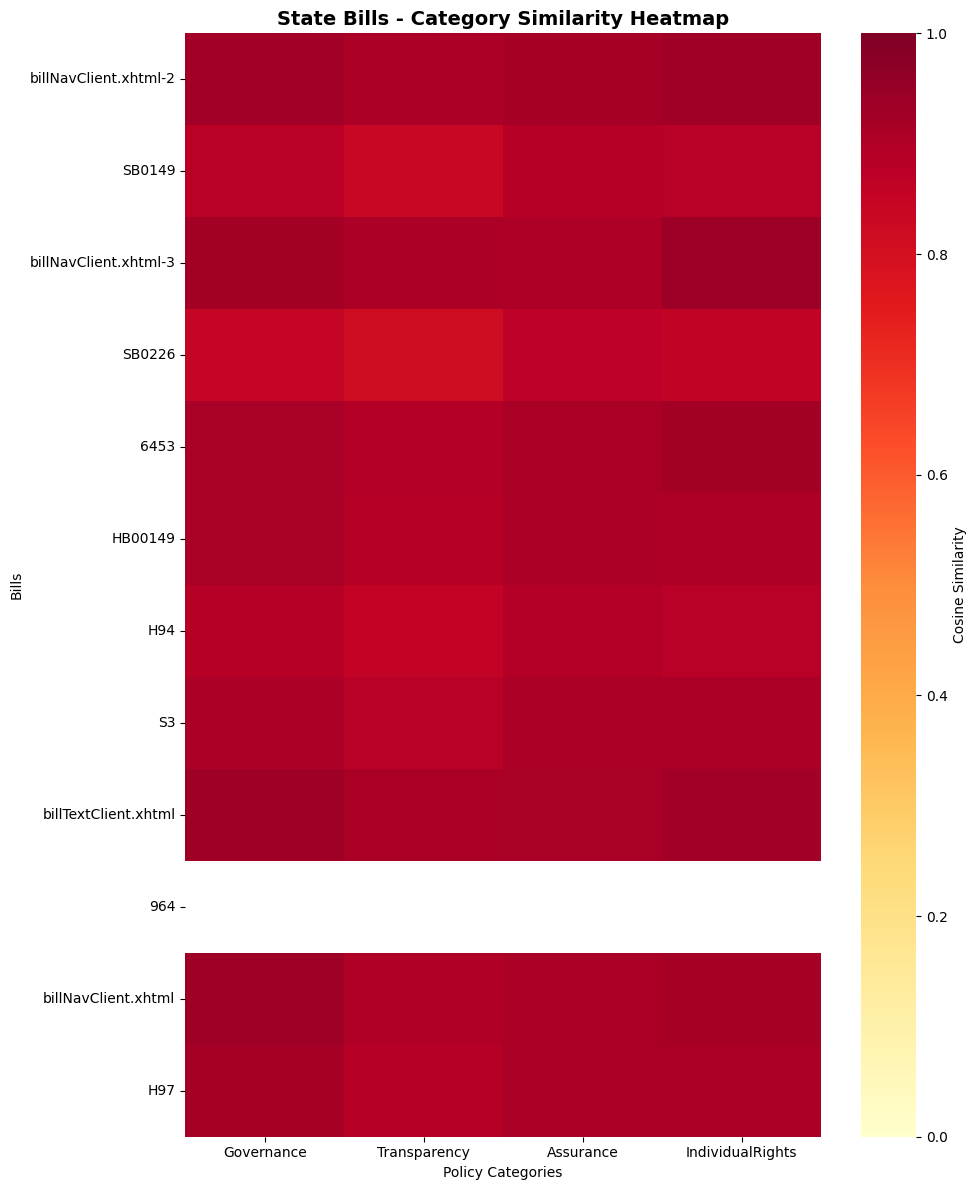

In [ ]:
# Heatmap: State Bills
plt.figure(figsize=(10, 12))
state_data = sim_df[sim_df["is_state"] == True][["Governance", "Transparency", "Assurance", "IndividualRights"]]
sns.heatmap(
    state_data,
    cmap="YlOrRd",
    cbar_kws={'label': 'Cosine Similarity'},
    yticklabels=sim_df[sim_df["is_state"] == True]["bill_number"].values,
    vmin=0,
    vmax=1
)
plt.title("State Bills - Category Similarity Heatmap", fontsize=14, fontweight='bold')
plt.xlabel("Policy Categories")
plt.ylabel("Bills")
plt.tight_layout()
plt.show()

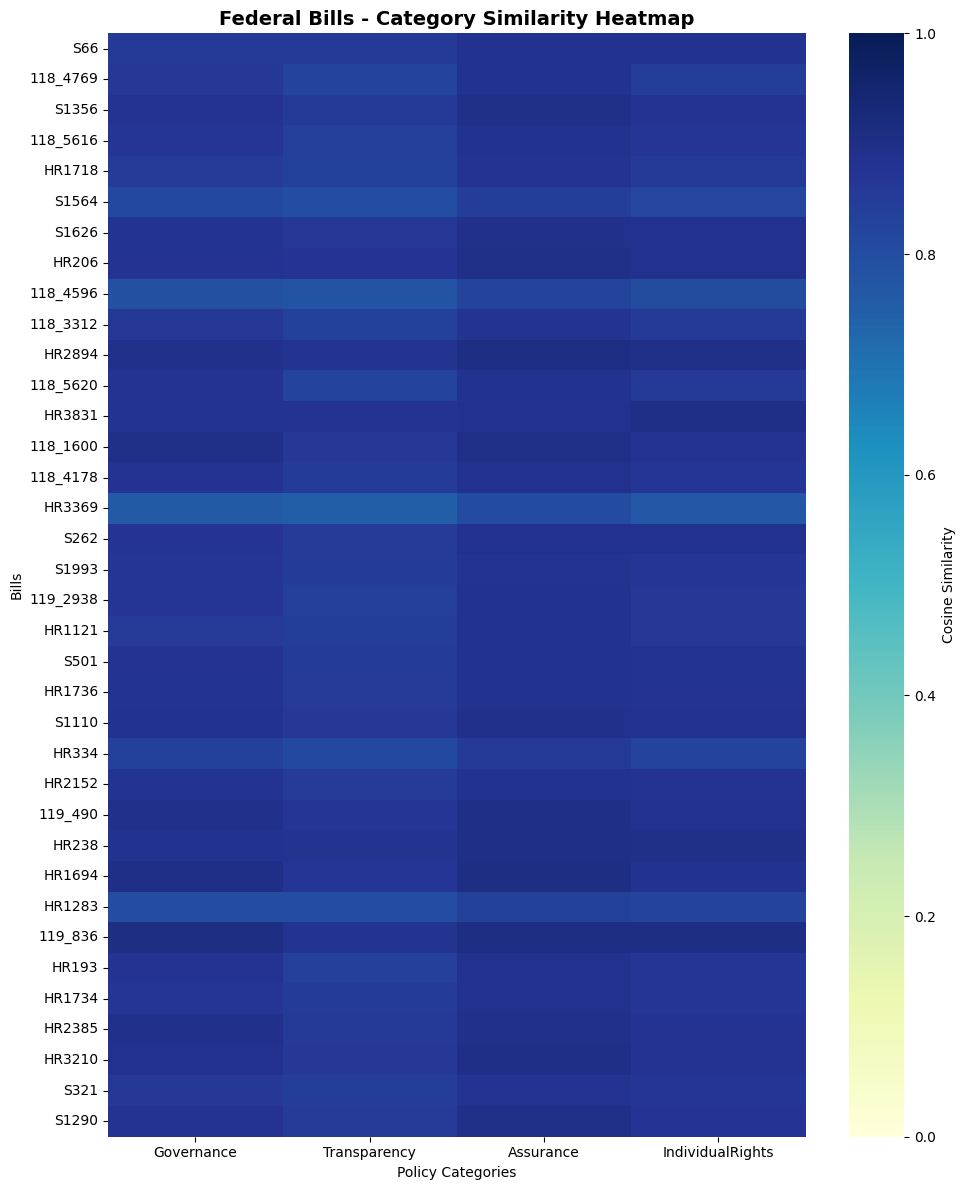

In [ ]:
# Heatmap: Federal Bills
plt.figure(figsize=(10, 12))
fed_data = sim_df[sim_df["is_state"] == False][["Governance", "Transparency", "Assurance", "IndividualRights"]]
sns.heatmap(
    fed_data,
    cmap="YlGnBu",
    cbar_kws={'label': 'Cosine Similarity'},
    yticklabels=sim_df[sim_df["is_state"] == False]["bill_number"].values,
    vmin=0,
    vmax=1
)
plt.title("Federal Bills - Category Similarity Heatmap", fontsize=14, fontweight='bold')
plt.xlabel("Policy Categories")
plt.ylabel("Bills")
plt.tight_layout()
plt.show()

/tmp/ipython-input-816305803.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["State", "Federal"], patch_artist=True)
/tmp/ipython-input-816305803.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["State", "Federal"], patch_artist=True)
/tmp/ipython-input-816305803.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["State", "Federal"], patch_artist=True)
/tmp/ipython-input-816305803.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplo

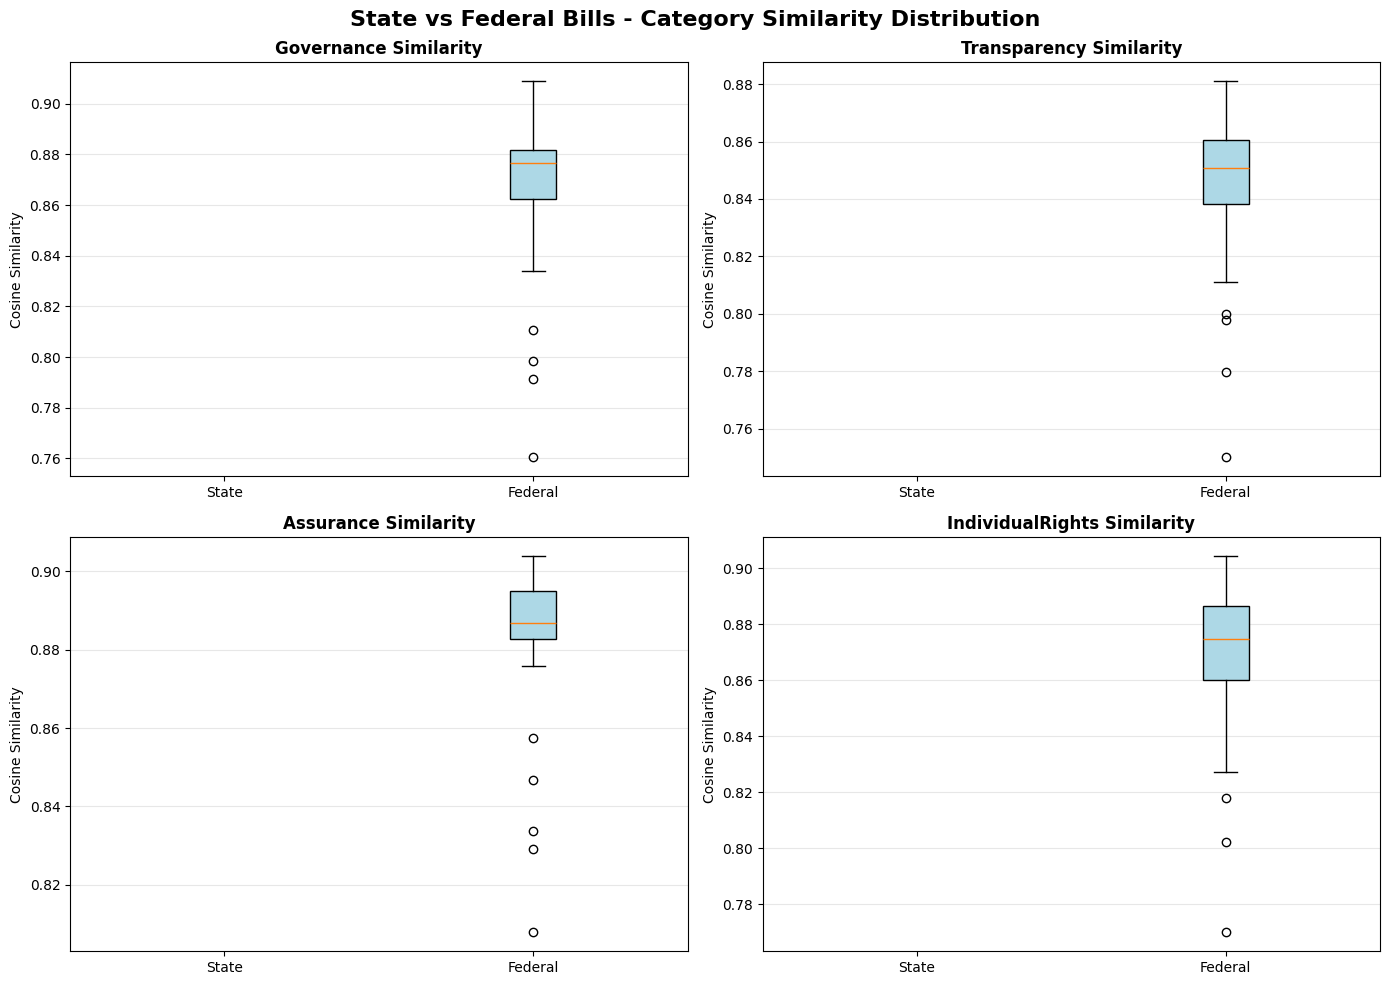

In [ ]:
# Box plot comparison: State vs Federal
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
categories = ["Governance", "Transparency", "Assurance", "IndividualRights"]

for idx, cat in enumerate(categories):
    ax = axes[idx // 2, idx % 2]

    data_to_plot = [
        state_sim[cat].values,
        fed_sim[cat].values
    ]

    bp = ax.boxplot(data_to_plot, labels=["State", "Federal"], patch_artist=True)

    # Color boxes
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightblue')

    ax.set_title(f"{cat} Similarity", fontweight='bold')
    ax.set_ylabel("Cosine Similarity")
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("State vs Federal Bills - Category Similarity Distribution",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2478586138.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, positions=positions,
/tmp/ipython-input-2478586138.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, positions=positions,
/tmp/ipython-input-2478586138.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, positions=positions,
/tmp/ipython-input-2478586138.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot

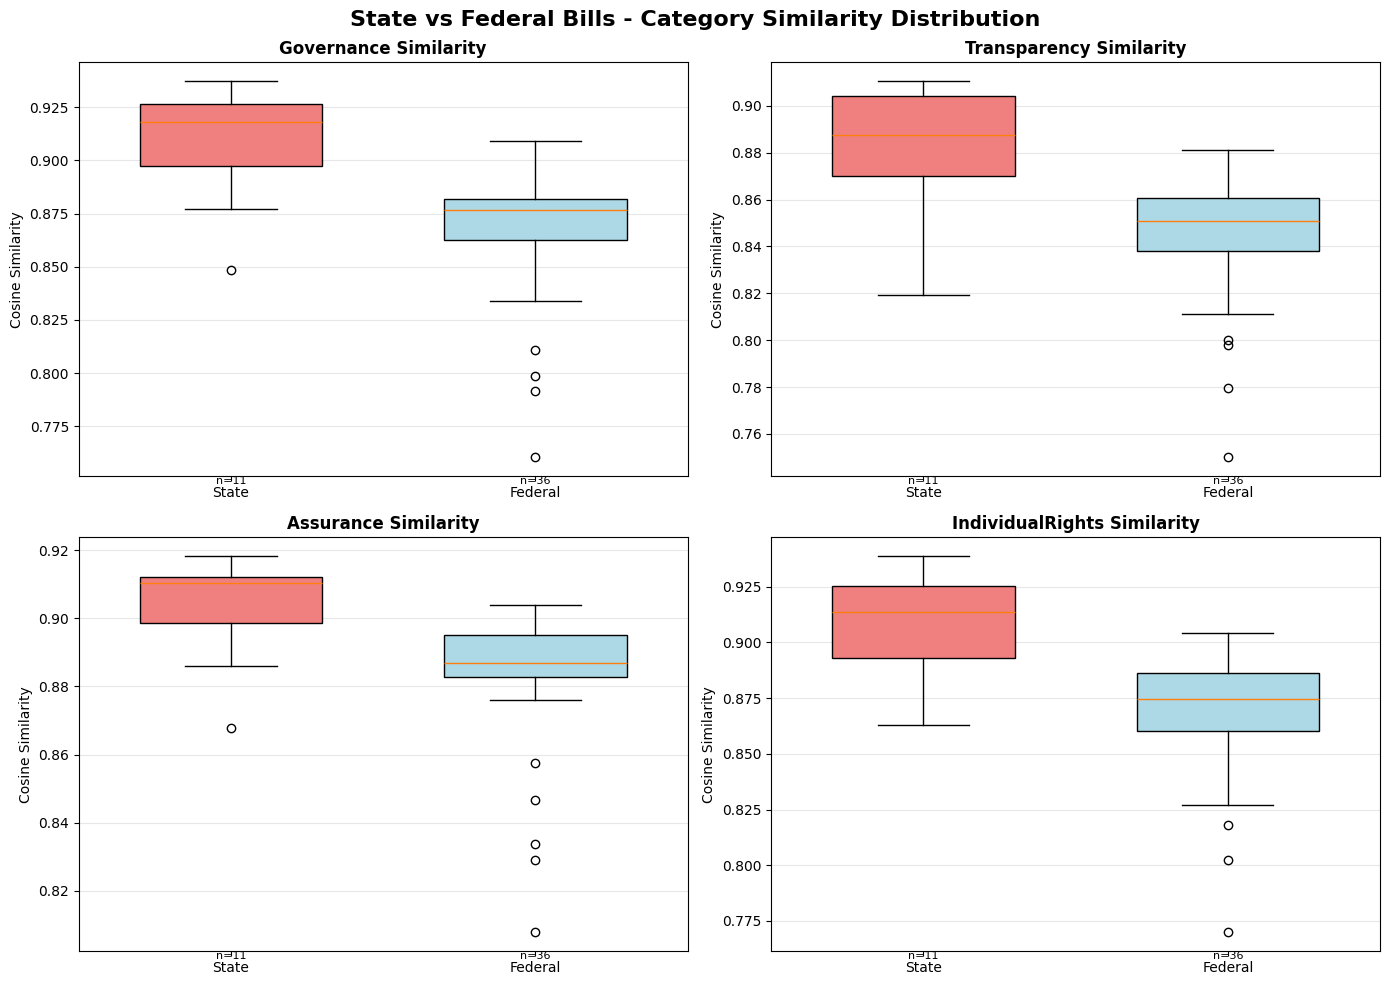

In [ ]:
import matplotlib.pyplot as plt

# Determine if state and federal bills exist in the similarity dataframes
has_state = not state_sim.empty
has_federal = not fed_sim.empty

# Box plot comparison: State vs Federal (FIXED VERSION)
if has_state and has_federal:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    categories = ["Governance", "Transparency", "Assurance", "IndividualRights"]

    for idx, cat in enumerate(categories):
        ax = axes[idx // 2, idx % 2]

        state_data = state_sim[cat].dropna().values
        fed_data = fed_sim[cat].dropna().values

        # Create positions for boxes
        positions = [1, 2]
        data_to_plot = [state_data, fed_data]

        bp = ax.boxplot(data_to_plot, positions=positions,
                        labels=["State", "Federal"],
                        patch_artist=True,
                        widths=0.6)

        # Color boxes
        bp['boxes'][0].set_facecolor('lightcoral')
        bp['boxes'][1].set_facecolor('lightblue')

        ax.set_title(f"{cat} Similarity", fontweight='bold', fontsize=12)
        ax.set_ylabel("Cosine Similarity", fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xlim(0.5, 2.5)

        # Add sample sizes
        ax.text(1, ax.get_ylim()[0], f'n={len(state_data)}',
                ha='center', va='top', fontsize=8)
        ax.text(2, ax.get_ylim()[0], f'n={len(fed_data)}',
                ha='center', va='top', fontsize=8)

    plt.suptitle("State vs Federal Bills - Category Similarity Distribution",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

elif has_federal and not has_state:
    print("⚠️ Only federal bills available - showing federal distribution only")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    categories = ["Governance", "Transparency", "Assurance", "IndividualRights"]

    for idx, cat in enumerate(categories):
        ax = axes[idx // 2, idx % 2]

        fed_data = fed_sim[cat].dropna().values

        bp = ax.boxplot([fed_data], labels=["Federal"],
                        patch_artist=True, widths=0.6)
        bp['boxes'][0].set_facecolor('lightblue')

        ax.set_title(f"{cat} Similarity (Federal Only)", fontweight='bold', fontsize=12)
        ax.set_ylabel("Cosine Similarity", fontsize=10)
        ax.grid(axis='y', alpha=0.3)

        # Add statistics
        ax.text(1, ax.get_ylim()[1]*0.95,
                f'Mean: {fed_data.mean():.3f}\nn={len(fed_data)}',
                ha='center', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle("Federal Bills - Category Similarity Distribution",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-1405099096.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cat_data, x='Type', y='Similarity',
/tmp/ipython-input-1405099096.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cat_data, x='Type', y='Similarity',
/tmp/ipython-input-1405099096.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cat_data, x='Type', y='Similarity',
/tmp/ipython-input-1405099096.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

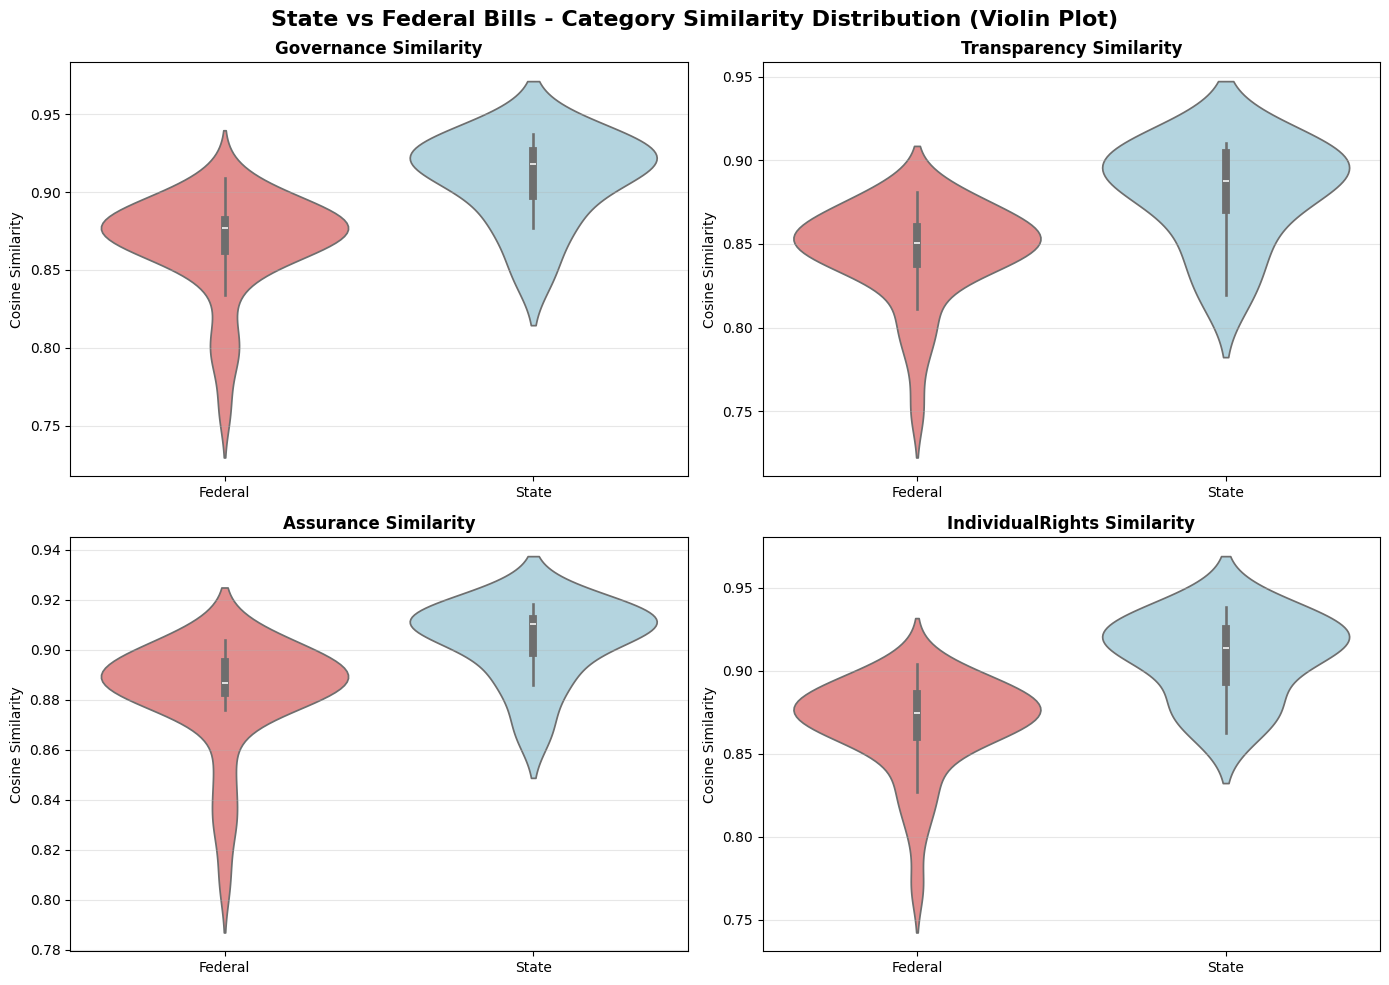

In [ ]:
# Alternative visualization: Violin plot (works better with uneven sample sizes)
if has_state and has_federal:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    categories = ["Governance", "Transparency", "Assurance", "IndividualRights"]

    # Prepare data in long format for seaborn
    plot_data = []
    for cat in categories:
        for _, row in sim_df.iterrows():
            plot_data.append({
                'Category': cat,
                'Similarity': row[cat],
                'Type': 'State' if row['is_state'] else 'Federal'
            })

    plot_df = pd.DataFrame(plot_data)

    for idx, cat in enumerate(categories):
        ax = axes[idx // 2, idx % 2]

        cat_data = plot_df[plot_df['Category'] == cat]

        sns.violinplot(data=cat_data, x='Type', y='Similarity',
                      palette=['lightcoral', 'lightblue'], ax=ax)

        ax.set_title(f"{cat} Similarity", fontweight='bold', fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel("Cosine Similarity", fontsize=10)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle("State vs Federal Bills - Category Similarity Distribution (Violin Plot)",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Top bills by category
print("\n" + "="*60)
print("TOP 5 BILLS BY CATEGORY SIMILARITY")
print("="*60)

for cat in ["Governance", "Transparency", "Assurance", "IndividualRights"]:
    print(f"\n{cat.upper()}:")
    top_5 = sim_df.nlargest(5, cat)[["bill_number", "is_state", cat]]
    for _, row in top_5.iterrows():
        bill_type = "STATE" if row["is_state"] else "FEDERAL"
        print(f"  {row['bill_number']:30s} ({bill_type}): {row[cat]:.3f}")


TOP 5 BILLS BY CATEGORY SIMILARITY

GOVERNANCE:
  billTextClient.xhtml           (STATE): 0.937
  billNavClient.xhtml            (STATE): 0.936
  billNavClient.xhtml-2          (STATE): 0.929
  billNavClient.xhtml-3          (STATE): 0.924
  H97                            (STATE): 0.919

TRANSPARENCY:
  billTextClient.xhtml           (STATE): 0.911
  billNavClient.xhtml-3          (STATE): 0.909
  billNavClient.xhtml-2          (STATE): 0.908
  billNavClient.xhtml            (STATE): 0.901
  6453                           (STATE): 0.894

ASSURANCE:
  billNavClient.xhtml-2          (STATE): 0.918
  billTextClient.xhtml           (STATE): 0.916
  6453                           (STATE): 0.913
  H97                            (STATE): 0.912
  S3                             (STATE): 0.912

INDIVIDUALRIGHTS:
  billNavClient.xhtml-3          (STATE): 0.939
  billNavClient.xhtml-2          (STATE): 0.933
  billTextClient.xhtml           (STATE): 0.928
  6453                           (STATE):

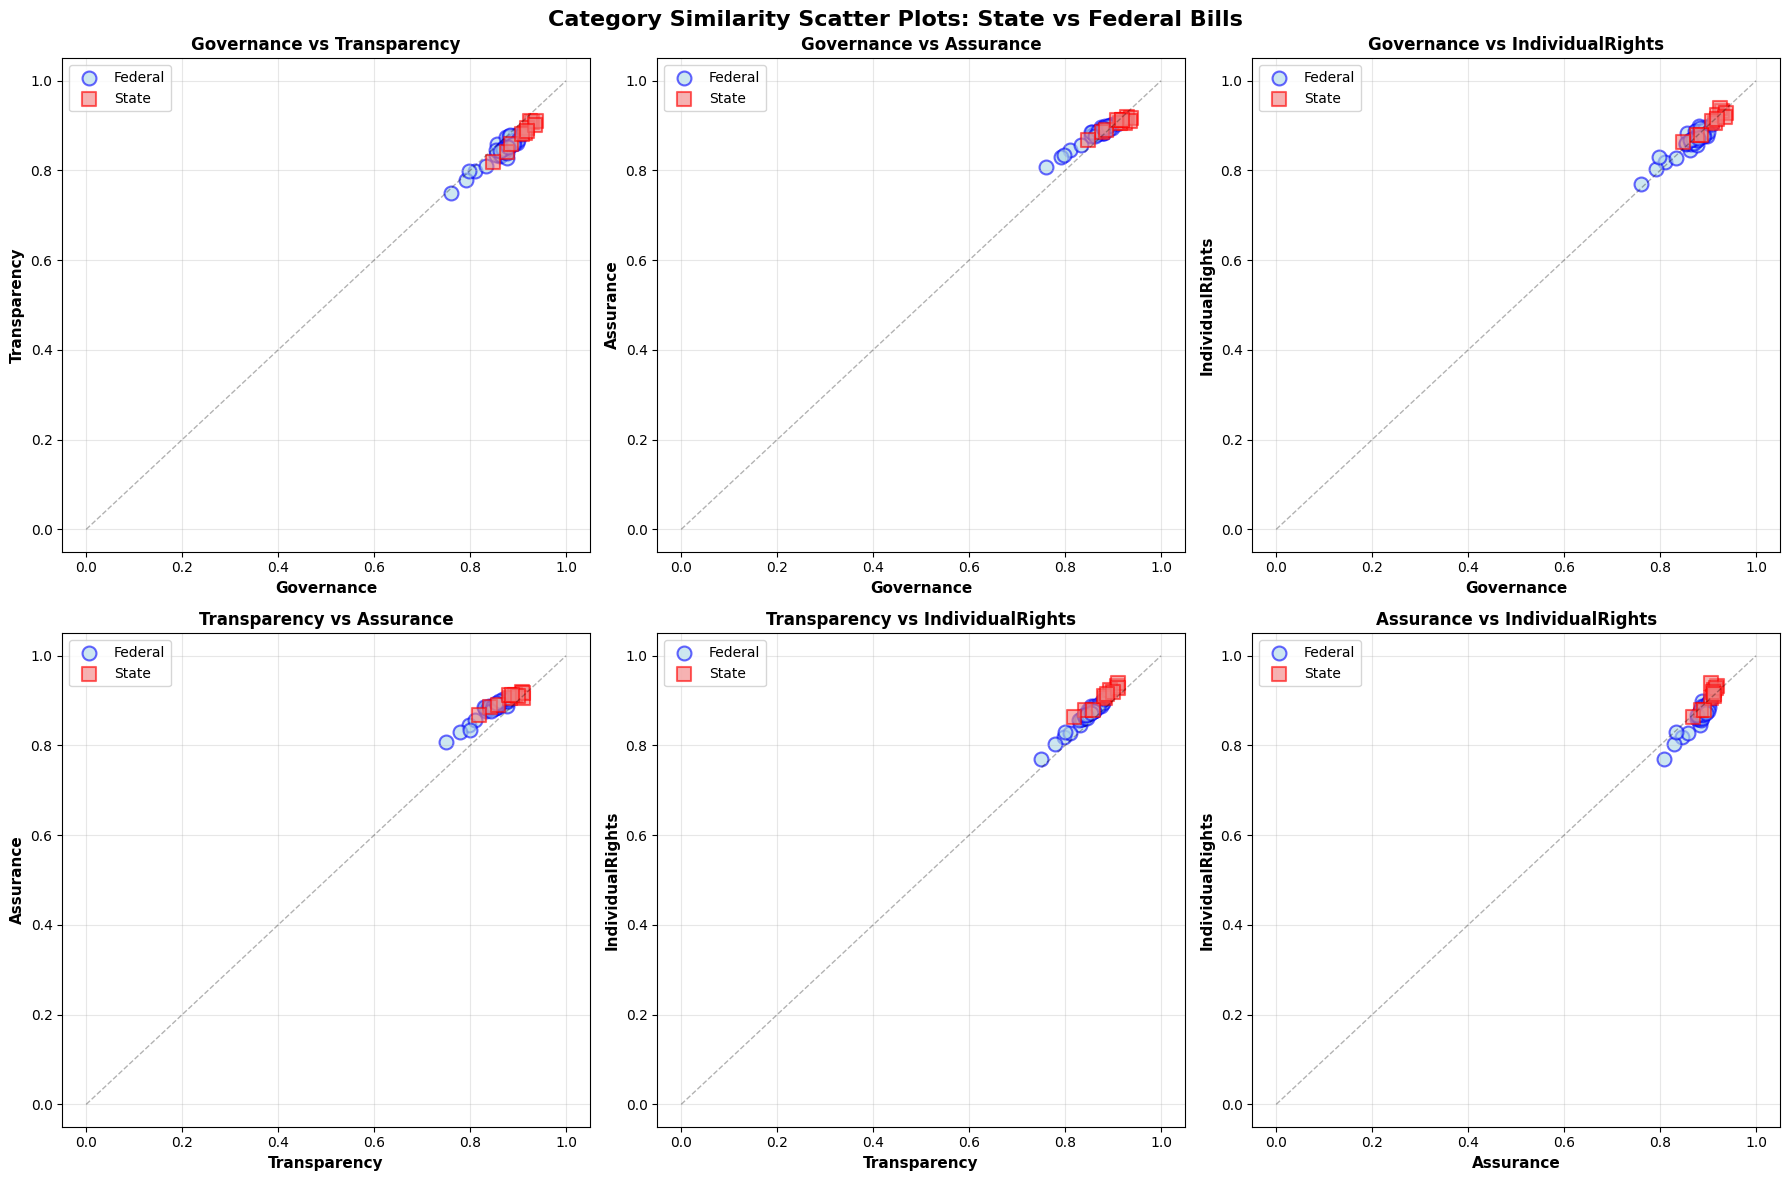

In [ ]:
# Scatter plot: Compare two categories at a time
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# All possible pairs of categories
category_pairs = [
    ("Governance", "Transparency"),
    ("Governance", "Assurance"),
    ("Governance", "IndividualRights"),
    ("Transparency", "Assurance"),
    ("Transparency", "IndividualRights"),
    ("Assurance", "IndividualRights")
]

for idx, (cat1, cat2) in enumerate(category_pairs):
    ax = axes[idx]

    # Plot federal bills
    fed_data = sim_df[sim_df["is_state"] == False]
    ax.scatter(fed_data[cat1], fed_data[cat2],
              c='lightblue', s=100, alpha=0.6,
              edgecolors='blue', linewidth=1.5,
              label='Federal', marker='o')

    # Plot state bills (if any)
    state_data = sim_df[sim_df["is_state"] == True]
    if len(state_data) > 0:
        ax.scatter(state_data[cat1], state_data[cat2],
                  c='lightcoral', s=100, alpha=0.6,
                  edgecolors='red', linewidth=1.5,
                  label='State', marker='s')

    ax.set_xlabel(cat1, fontsize=11, fontweight='bold')
    ax.set_ylabel(cat2, fontsize=11, fontweight='bold')
    ax.set_title(f"{cat1} vs {cat2}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

    # Add diagonal reference line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)

plt.suptitle("Category Similarity Scatter Plots: State vs Federal Bills",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

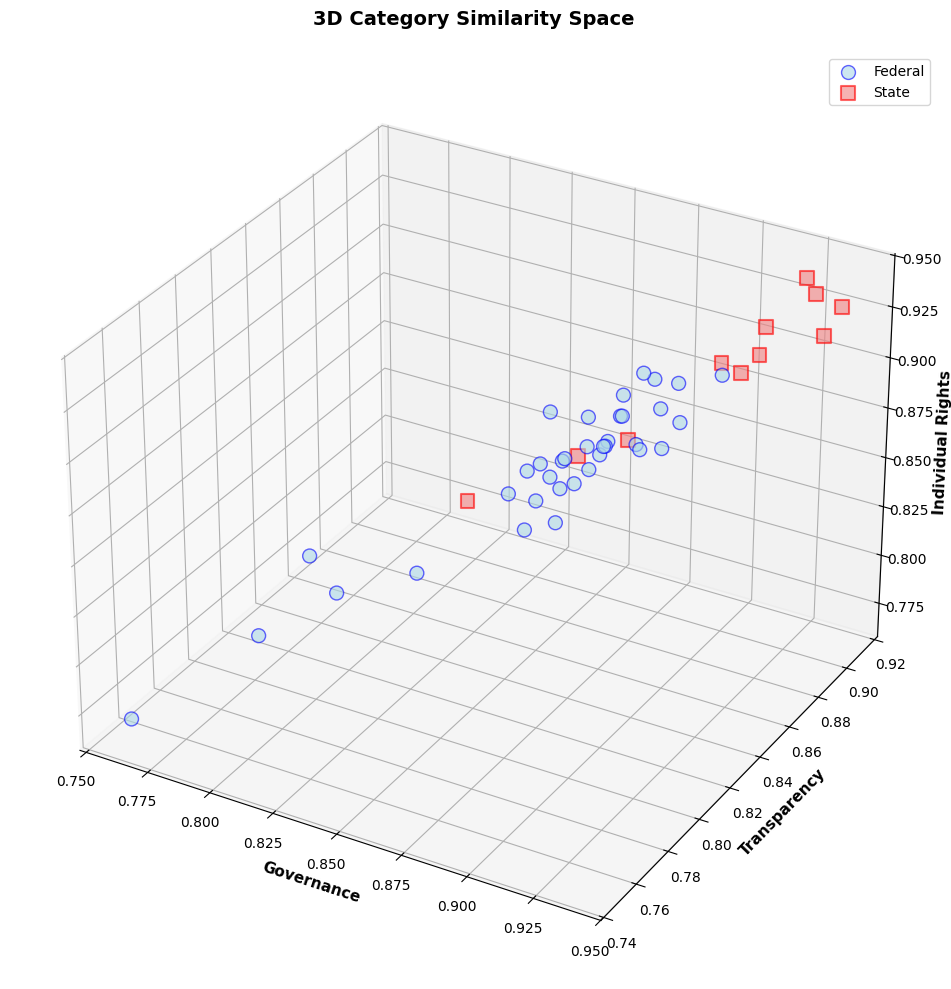

In [ ]:
# Interactive 3D Scatter Plot (pick 3 main categories)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot federal bills
fed_data = sim_df[sim_df["is_state"] == False]
ax.scatter(fed_data["Governance"],
          fed_data["Transparency"],
          fed_data["IndividualRights"],
          c='lightblue', s=100, alpha=0.6,
          edgecolors='blue', linewidth=1,
          label='Federal', marker='o')

# Plot state bills (if any)
state_data = sim_df[sim_df["is_state"] == True]
if len(state_data) > 0:
    ax.scatter(state_data["Governance"],
              state_data["Transparency"],
              state_data["IndividualRights"],
              c='lightcoral', s=100, alpha=0.6,
              edgecolors='red', linewidth=1.5,
              label='State', marker='s')

ax.set_xlabel('Governance', fontsize=11, fontweight='bold')
ax.set_ylabel('Transparency', fontsize=11, fontweight='bold')
ax.set_zlabel('Individual Rights', fontsize=11, fontweight='bold')
ax.set_title('3D Category Similarity Space', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

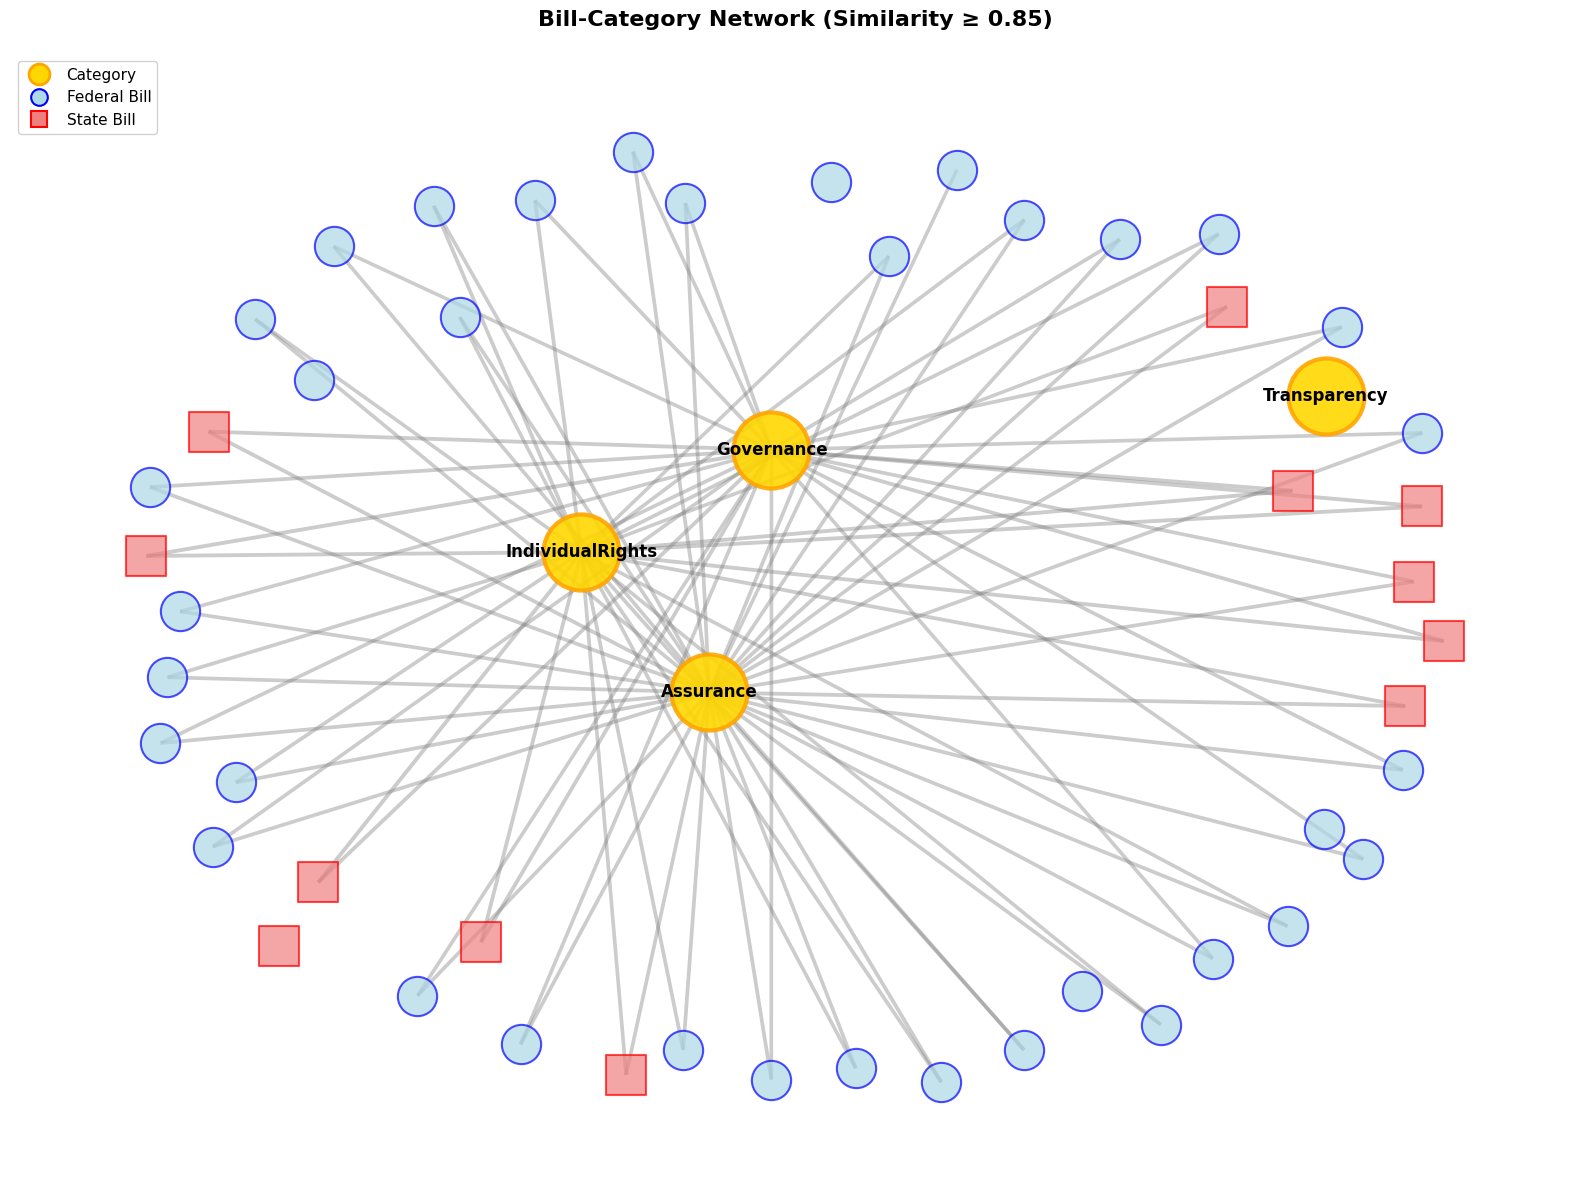


Network Statistics:
  Total nodes: 52
  Total edges: 85
  Category nodes: 4
  Federal bills: 36
  State bills: 12


In [ ]:
import networkx as nx
from matplotlib.patches import FancyBboxPatch

# Create network showing bills and their strongest category associations
G = nx.Graph()

# Add category nodes (central hubs)
categories = ["Governance", "Transparency", "Assurance", "IndividualRights"]
for cat in categories:
    G.add_node(cat, node_type='category')

# Add bill nodes and connect to their top 2 categories
threshold = 0.85  # Only show strong connections

for _, row in sim_df.iterrows():
    bill_id = row["bill_number"]
    bill_type = "State" if row["is_state"] else "Federal"

    G.add_node(bill_id, node_type='bill', bill_type=bill_type)

    # Get top 2 categories for this bill
    cat_scores = {cat: row[cat] for cat in categories}
    top_cats = sorted(cat_scores.items(), key=lambda x: x[1], reverse=True)[:2]

    for cat, score in top_cats:
        if score >= threshold:  # Only strong connections
            G.add_edge(bill_id, cat, weight=score)

# Layout
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw
plt.figure(figsize=(16, 12))

# Draw category nodes (large, central)
category_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'category']
nx.draw_networkx_nodes(G, pos, nodelist=category_nodes,
                       node_color='gold', node_size=3000,
                       alpha=0.9, node_shape='o',
                       edgecolors='orange', linewidths=3)

# Draw bill nodes (colored by type)
federal_bills = [n for n, d in G.nodes(data=True)
                if d.get('node_type') == 'bill' and d.get('bill_type') == 'Federal']
state_bills = [n for n, d in G.nodes(data=True)
              if d.get('node_type') == 'bill' and d.get('bill_type') == 'State']

if federal_bills:
    nx.draw_networkx_nodes(G, pos, nodelist=federal_bills,
                          node_color='lightblue', node_size=800,
                          alpha=0.7, node_shape='o',
                          edgecolors='blue', linewidths=1.5)

if state_bills:
    nx.draw_networkx_nodes(G, pos, nodelist=state_bills,
                          node_color='lightcoral', node_size=800,
                          alpha=0.7, node_shape='s',
                          edgecolors='red', linewidths=1.5)

# Draw edges (thickness by similarity score)
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
nx.draw_networkx_edges(G, pos, width=[w*3 for w in weights],
                       alpha=0.4, edge_color='gray')

# Labels (only for category nodes)
category_labels = {n: n for n in category_nodes}
nx.draw_networkx_labels(G, pos, labels=category_labels,
                       font_size=12, font_weight='bold',
                       font_color='black')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gold',
           markersize=15, label='Category', markeredgecolor='orange', markeredgewidth=2),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
           markersize=12, label='Federal Bill', markeredgecolor='blue', markeredgewidth=1.5),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='lightcoral',
           markersize=12, label='State Bill', markeredgecolor='red', markeredgewidth=1.5)
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

plt.title(f"Bill-Category Network (Similarity ≥ {threshold})",
         fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nNetwork Statistics:")
print(f"  Total nodes: {G.number_of_nodes()}")
print(f"  Total edges: {G.number_of_edges()}")
print(f"  Category nodes: {len(category_nodes)}")
print(f"  Federal bills: {len(federal_bills)}")
print(f"  State bills: {len(state_bills)}")